# CodeAlpha Web Scraping Project

## Objective
This project extracts book data from an online bookstore website using Python.

## Tools Used
- Python
- BeautifulSoup
- Pandas
- Requests

## Data Extracted
- Book Title
- Price
- Rating

1. INSTALL LIBRARIES

In [1]:
!pip install beautifulsoup4 requests pandas

2. IMPORT LIBRARIES

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

3. CONNECT TO WEBSITE

In [4]:
url = "https://books.toscrape.com/"

response = requests.get(url)

print(response.status_code)

200


4. UNDERSTAND HTML

In [5]:
soup = BeautifulSoup(response.text, 'html.parser')

print(soup.prettify()[:1000])

<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!-->
<html class="no-js" lang="en-us">
 <!--<![endif]-->
 <head>
  <title>
   All products | Books to Scrape - Sandbox
  </title>
  <meta content="text/html; charset=utf-8" http-equiv="content-type"/>
  <meta content="24th Jun 2016 09:29" name="created"/>
  <meta content="" name="description"/>
  <meta content="width=device-width" name="viewport"/>
  <meta content="NOARCHIVE,NOCACHE" name="robots"/>
  <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
  <!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->
  <link href="static/oscar/favicon.ico" rel="shortcut icon"/>
  <link href="static/oscar/css/styles.css" rel="stylesheet" type="tex

9. FIND ALL BOOKS

In [6]:
books = soup.find_all('article', class_='product_pod')

print(len(books))

20


10. EXTRACT BOOK TITLE

In [7]:
first_book = books[0]

title = first_book.h3.a['title']

print(title)

A Light in the Attic


11. EXTRACT PRICE


In [8]:
price = first_book.find('p', class_='price_color').text

print(price)

Â£51.77


12. EXTRACT RATING

In [9]:
rating = first_book.p['class'][1]

print(rating)

Three


13. EXTRACT ALL BOOK DATA

In [10]:
titles = []
prices = []
ratings = []

for book in books:

    title = book.h3.a['title']

    price = book.find('p', class_='price_color').text

    rating = book.p['class'][1]

    titles.append(title)
    prices.append(price)
    ratings.append(rating)

14. CREATE TABLE

In [11]:
df = pd.DataFrame({
    'Title': titles,
    'Price': prices,
    'Rating': ratings
})

df.head()

,Title,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five


In [13]:
df['Price'] = df['Price'].str.replace('Â£', '').astype(float)

# Mapping for ratings
rating_map = {
    'One': 1,
    'Two': 2,
    'Three': 3,
    'Four': 4,
    'Five': 5
}

df['Rating_Numeric'] = df['Rating'].map(rating_map)

In [14]:
average_price_per_rating = df.groupby('Rating_Numeric')['Price'].mean().sort_index()
print("Average Price per Rating:\n", average_price_per_rating)

Average Price per Rating:
 Rating_Numeric
1    40.018333
2    36.830000
3    42.316667
4    31.105000
5    39.750000
Name: Price, dtype: float64


15. AVERAGE PRICE PER RATING CATEGORY USING A BAR CHART

/tmp/ipykernel_8684/1657839716.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_price_per_rating.index, y=average_price_per_rating.values, palette='viridis')


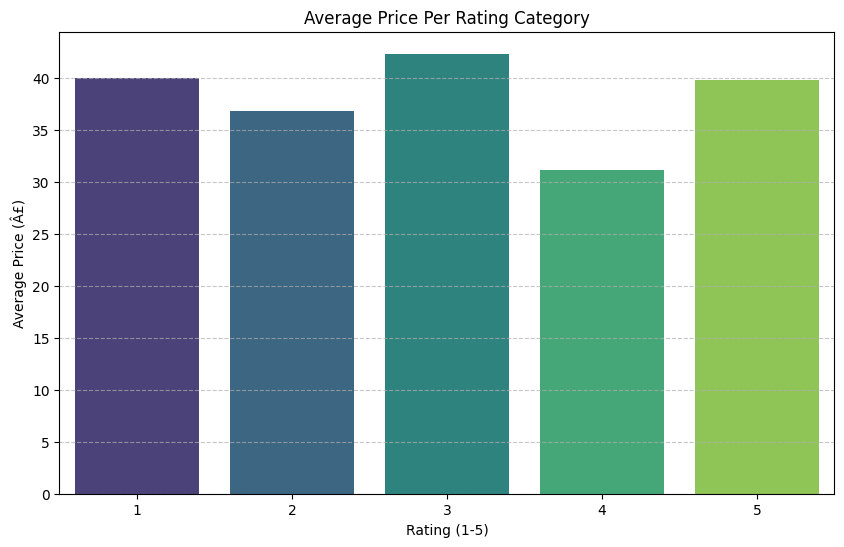

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=average_price_per_rating.index, y=average_price_per_rating.values, palette='viridis')
plt.title('Average Price Per Rating Category')
plt.xlabel('Rating (1-5)')
plt.ylabel('Average Price (Â£)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

16. SAVE CSV FILE

In [15]:
df.to_csv("books_data.csv", index=False)

17. DOWNLOAD CSV

In [17]:
from google.colab import files
files.download('books_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>